### **Laplace Equation**

Laplace's equation describes steady-state problems dominated exclusively by diffusive mechanisms, with no internal generation. It is governed by the equation:

$$
    \nabla^{2} \phi = 0
$$

### **Problem Definition**

Consider the domain $\Omega = [0,1]^2$, whose boundary is given by $\partial \Omega = \Gamma_N \cup \Gamma_E \cup \Gamma_S \cup \Gamma_W$, where $\Gamma_N = [0,1] \times \{1\}$, $\Gamma_E = \{1\} \times [0,1]$, $\Gamma_S = [0,1] \times \{0\}$ and $\Gamma_W = \{0\} \times [0,1]$. In this context, the problem is defined by Equation \ref{eq:appendices-laplace-system}, from the differential equation defined on $\Omega$ and the boundary conditions defined on $\partial \Omega$.

$$
\begin{cases}
    \nabla^2\phi(x,y)=0, & (x,y)\in\Omega \\
    \mathcal{B}[\phi]=0, & (x,y)\in\partial\Omega
\end{cases}
$$

This tutorial deals with Dirichlet boundary conditions defined by:

$$
    \mathcal{B}[\phi]:=\big\{\,\phi|_{\Gamma_N}=1,\;\phi|_{\Gamma_E}=0,\;\phi|_{\Gamma_S}=0,\;\phi|_{\Gamma_W}=0\,\big\}
$$

### **Analytical Solution**

The analytical solution of the Laplace equation in two-dimensional domains can be obtained by means of the method of separation of variables, assuming that the solution can be decomposed as the product of two functions, each dependent only on one of the spatial coordinates. The solution is:

$$
    \phi(x,y)=\sum_{\substack{n=1\\}}^{\infty} \frac{4}{\pi (2 n - 1)}\, \frac{\sinh((2 n - 1)\pi y)}{\sinh((2 n - 1)\pi)}\, \sin((2 n - 1)\pi x)
$$

### 1. Packages

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import torch
import numpy as np
import matplotlib.pyplot as plt

from math import floor
from typing import List, Mapping, Optional

from bernet.contracts import ISampler, ILoss, IMetrics, ILogger
from bernet.utils.statistics import lhs_1, lhs_d
from bernet.core.trainer import DFLTTrainer

### 2. Hyperparameters

In [2]:
#-- Model
neurons = [2, 10, 10, 1]
activation = torch.nn.Tanh()

#-- Sampler
spacing = 0.01
batch_size = 5
ratio = 0.1
obs_ratio = 0.1

#-- Optimizer
learning_rate = 1e-3
weight_decay = 1e-5

#-- Trainign
num_epochs = 10

### 3. Implementation

Model

In [ ]:
class Model(torch.nn.Module):

    def __init__(
        self,
        neurons: List[int],
        activation: torch.nn.Module,
        ) -> None:
        super(Model, self).__init__()

        #-- Define a sequential model
        self.net = torch.nn.Sequential()

        #-- Add layers
        for i in range(len(neurons) - 1):
            self.net.append(torch.nn.Linear(neurons[i], neurons[i + 1]))
            if i < len(neurons) - 2:
                self.net.append(activation)
        
        return

    def forward(
        self,
        x: torch.Tensor,
        y: torch.Tensor,
        ) -> torch.Tensor:

        #-- Concatenate inputs
        inputs = torch.concat([x, y], dim=1)

        #-- Forward pass
        phi = self.net(inputs)

        return phi

Analytical Solution

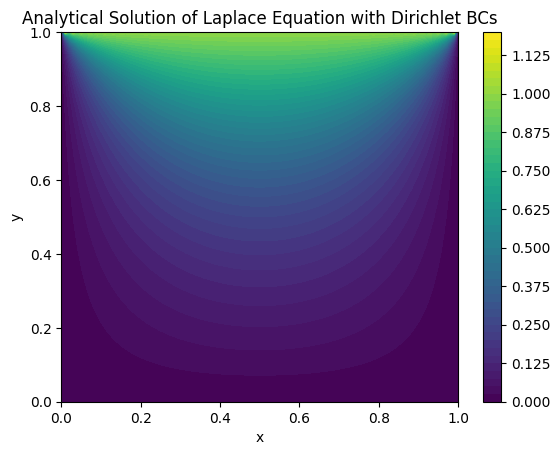

In [4]:
#- Analytical solution
def analytical_solution(
    x: np.ndarray,
    y: np.ndarray,
    n: int,
    ) -> np.ndarray:
    """
    Computes the analytical solution of the Laplace equation
    with Dirichlet boundary conditions.

    Parameters:
    ----------
    - x : np.ndarray
      > x-coordinates of the points.
    - y : np.ndarray
      > y-coordinates of the points.
    - n : int
      > Number of terms in the series expansion.
    
    Returns:
    -------
    - phi : np.ndarray
      > Analytical solution at the given points.
    """

    #-- Define the indexes of the series
    #   (only odd indexes are used)
    indexes = np.arange(1, n + 1, 2, dtype=float)

    #-- Save the shape of the spatial coordinates
    shape = x.shape

    #-- Reshape the spatial coordinates
    x_i = x.flatten()
    y_i = y.flatten()

    #-- Reshape for broadcasting
    indexes = indexes[:, None]
    x_i = x_i[None, :]
    y_i = y_i[None, :]

    # Compute the terms, shape: (num_terms, N)
    term = (4.0 / (np.pi * indexes)) * \
           (np.sinh(indexes * np.pi * y_i) / np.sinh(indexes * np.pi)) * \
           np.sin(indexes * np.pi * x_i)
    
    #-- Sum over the series dimension (axis=0), result shape: (N,)
    phi = term.sum(axis=0)

    #-- Reshape to the original shape
    phi = phi.reshape(shape)

    return phi

#-- Testing the analytical solution
if __name__ == "__main__":
    
    #-- Define the spatial domain
    x = np.linspace(0, 1, 100)
    y = np.linspace(0, 1, 100)
    X, Y = np.meshgrid(x, y)

    #-- Compute the analytical solution
    phi = analytical_solution(X, Y, n=100)

    #-- Plot the solution
    plt.figure()
    cp = plt.contourf(X, Y, phi, levels=50, cmap='viridis')
    plt.colorbar(cp)
    plt.title('Analytical Solution of Laplace Equation with Dirichlet BCs')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()


Contracts

In [ ]:
class Sampler(ISampler):

    def __init__(
            self,
            spacing: float,
            batch_size: int = 10,
            ratio: float = 0.1,
            obs_ratio: Optional[float] = None,
        ) -> None:
        """
        Parameters:
        ----------
        - spacing : float
        > Mean distance between nodes.
        - batch_size : int
        > The number of samples per batch.
        - ratio: float
        > Ratio between the number of testing and training samples.
        """
        
        #-- Inputs
        self.spacing = spacing
        self.batch_size = batch_size
        self.ratio = ratio
        self.obs_ratio = obs_ratio

        #-- Auxiliary parameters
        self.current_batch = -1

        #-- Create points
        p_int, p_bc = self._sample_points()

        #-- Split training and testing data
        p_int_train, p_col_test = self._train_test_split(x=p_int, r=self.ratio)
        p_bc_train, p_bc_test = self._train_test_split(x=p_bc, r=self.ratio)

        #-- Split collocation and data points
        if self.obs_ratio is not None:
            p_col_train, p_data_train = self._train_test_split(x=p_int_train, r=self.obs_ratio)
        else:
            p_col_train, p_data_train = p_int_train, None

        #-- Required parameter
        self.num_batches = 10 # int( (p_int_train.shape[0] + p_bc_train.shape[0]) / self.batch_size )

        #-- Split data into batches
        self.batches_data = self._create_batches(p_col=p_col_train, p_bc=p_bc_train, p_data=p_data_train)
        self.num_batches = len(self.batches_data)

        #-- Define metrics dataset
        self.metrics_data = self._create_metrics(p_col=p_col_test, p_bc=p_bc_test)

        return
    
    def _create_metrics(self, p_col: np.ndarray, p_bc: np.ndarray) -> Mapping[str, torch.Tensor]:

        p = np.concat([p_col, p_bc], axis=0)

        data = {
            "x": torch.tensor(p[:, 0], dtype=torch.float32).view(-1, 1),
            "y": torch.tensor(p[:, 1], dtype=torch.float32).view(-1, 1),
            "phi": torch.tensor(p[:, 2], dtype=torch.float32).view(-1, 1),
        }

        return data
    
    def _create_batches(self, p_col: np.ndarray, p_bc: np.ndarray, p_data: np.ndarray, ) -> List[Mapping[str, torch.Tensor]]:

        #-- Compute the batch size of each dataset
        batch_size_col = floor(p_col.shape[0] / self.num_batches)
        batch_size_data = floor(p_data.shape[0] / self.num_batches)
        batch_size_bc = floor(p_bc.shape[0] / self.num_batches)

        #-- Create the batches
        batches = []

        for i in range(self.num_batches):    
            #-- Aplit arrays
            if i == self.num_batches - 1:
                residual = {
                    "x_col": torch.tensor(p_col[batch_size_col * i:, 0], dtype=torch.float32).view(-1, 1),
                    "y_col": torch.tensor(p_col[batch_size_col * i:, 1], dtype=torch.float32).view(-1, 1),
                }
                boundary = {
                    "x_bc": torch.tensor(p_bc[batch_size_bc * i:, 0], dtype=torch.float32).view(-1, 1),
                    "y_bc": torch.tensor(p_bc[batch_size_bc * i:, 1], dtype=torch.float32).view(-1, 1),
                    "phi_bc": torch.tensor(p_bc[batch_size_bc * i:, 2], dtype=torch.float32).view(-1, 1),
                }
                data = {
                    "x_data": torch.tensor(p_data[batch_size_data * i:, 0], dtype=torch.float32).view(-1, 1),
                    "y_data": torch.tensor(p_data[batch_size_data * i:, 1], dtype=torch.float32).view(-1, 1),
                    "phi_data": torch.tensor(p_data[batch_size_data * i:, 2], dtype=torch.float32).view(-1, 1),
                }

            else:
                residual = {
                    "x_col": torch.tensor(p_col[batch_size_col * i: batch_size_col * (i + 1), 0], dtype=torch.float32).view(-1, 1),
                    "y_col": torch.tensor(p_col[batch_size_col * i: batch_size_col * (i + 1), 1], dtype=torch.float32).view(-1, 1),
                }
                boundary = {
                    "x_bc": torch.tensor(p_bc[batch_size_bc * i: batch_size_bc * (i + 1), 0], dtype=torch.float32).view(-1, 1),
                    "y_bc": torch.tensor(p_bc[batch_size_bc * i: batch_size_bc * (i + 1), 1], dtype=torch.float32).view(-1, 1),
                    "phi_bc": torch.tensor(p_bc[batch_size_bc * i: batch_size_bc * (i + 1), 2], dtype=torch.float32).view(-1, 1),
                }
                data = {
                    "x_data": torch.tensor(p_data[batch_size_data * i: batch_size_data * (i + 1), 0], dtype=torch.float32).view(-1, 1),
                    "y_data": torch.tensor(p_data[batch_size_data * i: batch_size_data * (i + 1), 1], dtype=torch.float32).view(-1, 1),
                    "phi_data": torch.tensor(p_data[batch_size_data * i: batch_size_data * (i + 1), 2], dtype=torch.float32).view(-1, 1),
                }
            
            #-- Create batch
            batch = {
                "residual": residual,
                "boundary": boundary,
                "data": data,
            }

            #-- Append batch
            batches.append(batch)

        return batches

    def _train_test_split(
            self,
            x: np.ndarray,
            r: float,
        ) -> List[np.ndarray]:

        #-- Compute the number of rows for first array
        n = int(x.shape[0] * (1 - r))

        #-- Saplit array
        arr1 = x[:n, :]
        arr2 = x[n:, :]

        return [arr1, arr2]
    
    def _sample_points(self) -> List[np.ndarray]:

        #-- Auxiliary parameters
        n_col = int((1 / self.spacing) ** 2)    # Number of points inside the domain
        n_bc = int(1 / self.spacing)            # Number of points on each side

        #-- Collocation points
        p_col = np.empty(shape=[n_col, 3])

        p_col[:, :2] = lhs_d(n=n_col, d=2)
        p_col[:, 2] = analytical_solution(x=p_col[:, 0], y=p_col[:, 1], n=100)

        #-- Boundary points
        p_bc = np.empty(shape=[4 * n_bc, 3])

        #-  [x, 0]
        p_bc[:n_bc, 0] = lhs_1(n_bc)
        p_bc[:n_bc, 1] = 0.0
        p_bc[:n_bc, 2] = analytical_solution(x=p_bc[:n_bc, 0], y=p_bc[:n_bc, 1], n=100)

        #-  [x, 1]
        p_bc[n_bc:2 * n_bc, 0] = lhs_1(n_bc)
        p_bc[n_bc:2 * n_bc, 1] = 1.0
        p_bc[n_bc:2 * n_bc, 2] = analytical_solution(x=p_bc[n_bc:2 * n_bc, 0], y=p_bc[n_bc:2 * n_bc, 1], n=100)

        #-  [0, y]
        p_bc[2 * n_bc:3 * n_bc, 0] = 0.0
        p_bc[2 * n_bc:3 * n_bc, 1] = lhs_1(n_bc)
        p_bc[2 * n_bc:3 * n_bc, 2] = analytical_solution(x=p_bc[2 * n_bc:3 * n_bc, 0], y=p_bc[2 * n_bc:3 * n_bc, 1], n=100)

        #-  [1, y]
        p_bc[3 * n_bc:4 * n_bc, 0] = 1.0
        p_bc[3 * n_bc:4 * n_bc, 1] = lhs_1(n_bc)
        p_bc[3 * n_bc:4 * n_bc, 2] = analytical_solution(x=p_bc[3 * n_bc:4 * n_bc, 0], y=p_bc[3 * n_bc:4 * n_bc, 1], n=100)

        return [p_col, p_bc]

    #-- Necessary method
    def batch(self):
        if self.current_batch == self.num_batches - 1:
            self.current_batch = 0
        else:
            self.current_batch += 1
        return self.batches_data[self.current_batch]
    
    #-- Optional method
    def metrics(self):
        return self.metrics_data

class Loss(ILoss):

    def __init__(self):

        #-- Auxiliary loss functions
        self.mse = torch.nn.MSELoss()

        return
    
    def _residual(
        self,
        model: torch.nn.Module,
        batch: Mapping[str, torch.Tensor],
        ) -> torch.Tensor:

        #-- Get model inputs
        x = batch["x_col"]
        y = batch["y_col"]

        #-- Enable gradient computation
        x.requires_grad_(True)
        y.requires_grad_(True)

        #-- Compute phi
        phi = model(x, y)

        #-- First derivatives
        phi_x = torch.autograd.grad(phi, x, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
        phi_y = torch.autograd.grad(phi, y, grad_outputs=torch.ones_like(phi), create_graph=True)[0]

        #-- Second derivatives
        phi_xx = torch.autograd.grad(phi_x, x, grad_outputs=torch.ones_like(phi_x), create_graph=True)[0]
        phi_yy = torch.autograd.grad(phi_y, y, grad_outputs=torch.ones_like(phi_y), create_graph=True)[0]
        
        #-- Residuals
        residual = phi_xx + phi_yy

        #-- Loss
        loss = torch.mean(residual * residual)

        return 0.0 * loss
        
    def _boundary(
        self,
        model: torch.nn.Module,
        batch: Mapping[str, torch.Tensor],
        ) -> torch.Tensor:

        #-- Get model inputs
        x = batch["x_bc"]
        y = batch["y_bc"]
        phi_ref = batch["phi_bc"]

        #-- Compute phi
        phi = model(x, y)

        #-- Compute loss
        loss = self.mse(phi, phi_ref)

        return loss

    def _data(
        self,
        model: torch.nn.Module,
        batch: Mapping[str, torch.Tensor],
        ) -> torch.Tensor:

        #-- Get model inputs
        x = batch["x_data"]
        y = batch["y_data"]
        phi_ref = batch["phi_data"]

        #-- Compute phi
        phi = model(x, y)
        
        #-- Compute loss
        loss = self.mse(phi, phi_ref)

        return loss

class Metrics(IMetrics):

    def __init__(self):
        
        #-- Auxiliary loss functions
        self.mse = torch.nn.MSELoss()

        return
    
    def __call__(
        self,
        model: torch.nn.Module,
        data: Mapping[str, torch.nn.Module],
        ):
        
        #-- Get model inputs
        x = data["x"]
        y = data["y"]
        phi_ref = data["phi"]

        #-- Compute phi
        phi = model(x, y)

        #-- Mean squared error
        mse = self.mse(phi, phi_ref)

        #-- Create dictionary
        metrics = {"mse": mse.item()}

        return metrics

class Logger(ILogger):

    def __init__(self):
        self.data = {}
        return

### 4. Training

Setup

In [21]:
#-- Model
model = Model(
    neurons=neurons,
    activation=activation,
).to(torch.device("cpu"))

#-- Implementations
sampler = Sampler(
    spacing=spacing,
    batch_size=batch_size,
    ratio=ratio,
    obs_ratio=obs_ratio,
)

loss = Loss()
metrics = Metrics()
logger = Logger()

#-- Optimizer
optmizer = torch.optim.Adam(
    params=model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)

#-- Trainer
trainer = Trainer(
    model=model,
    sampler=sampler,
    loss=loss,
    optimizer=optmizer,
    metrics=metrics,
    logger=logger,
)

Fit

In [22]:
trainer.fit(num_epochs=1000, verbose=True)

Epoch 1/1000 - Resultados:
 > Total loss: 4.2490e-01
 > Loss terms:
    - residual: 0.0000e+00
    - boundary: 2.8972e-01
    - initial: 0.0000e+00
    - data: 1.3518e-01
 > Metrics:
    - residual: 0.0000e+00
    - boundary: 2.8972e-01
    - initial: 0.0000e+00
    - data: 1.3518e-01
Epoch 2/1000 - Resultados:
 > Total loss: 3.4466e-01
 > Loss terms:
    - residual: 0.0000e+00
    - boundary: 2.4578e-01
    - initial: 0.0000e+00
    - data: 9.8876e-02
 > Metrics:
    - residual: 0.0000e+00
    - boundary: 2.4578e-01
    - initial: 0.0000e+00
    - data: 9.8876e-02
Epoch 3/1000 - Resultados:
 > Total loss: 2.9069e-01
 > Loss terms:
    - residual: 0.0000e+00
    - boundary: 2.1495e-01
    - initial: 0.0000e+00
    - data: 7.5744e-02
 > Metrics:
    - residual: 0.0000e+00
    - boundary: 2.1495e-01
    - initial: 0.0000e+00
    - data: 7.5744e-02
Epoch 4/1000 - Resultados:
 > Total loss: 2.5661e-01
 > Loss terms:
    - residual: 0.0000e+00
    - boundary: 1.9425e-01
    - initial: 0.000

### 5. Results

Logger

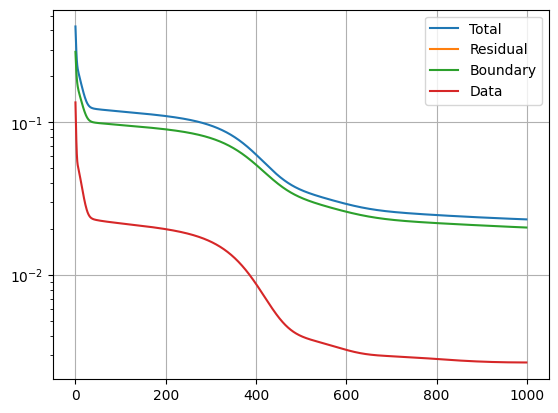

In [23]:
plt.figure()
plt.plot(logger.data["total_loss"], label="Total")
plt.plot(logger.data["residual"], label="Residual")
plt.plot(logger.data["boundary"], label="Boundary")
plt.plot(logger.data["data"], label="Data")
plt.legend()
plt.yscale("log")
plt.grid()
plt.show()

Field visualization

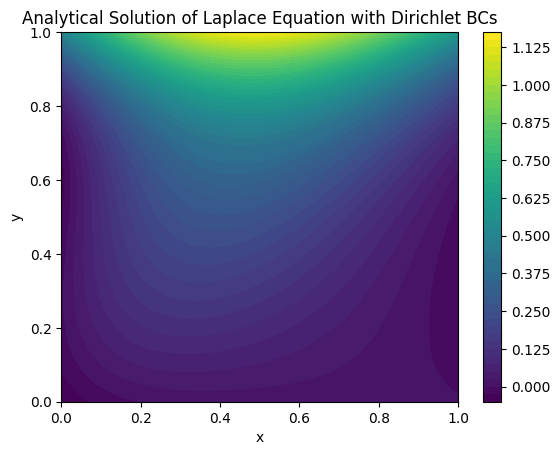

In [24]:
#-- Define the spatial domain
n = 100

x = np.linspace(0, 1, n)
y = np.linspace(0, 1, n)
X, Y = np.meshgrid(x, y)

#-- Convert to tensor
x_tensor = torch.tensor(X.reshape(-1, 1), dtype=torch.float32)
y_tensor = torch.tensor(Y.reshape(-1, 1), dtype=torch.float32)

#-- Compute the analytical solution
phi = model(x_tensor, y_tensor).detach().numpy()
phi = phi.reshape(n, n)

#-- Plot the solution
plt.figure()
cp = plt.contourf(X, Y, phi, levels=50, cmap='viridis')
plt.colorbar(cp)
plt.title('Analytical Solution of Laplace Equation with Dirichlet BCs')
plt.xlabel('x')
plt.ylabel('y')
plt.show()